# Notebook 04 — LLM, RAG y Sistema Multi-Agente
**Proyecto:** Sistema Multi-Agente para Análisis de Deserción Estudiantil

---
## Objetivos
1. Configurar el LLM gratuito (Groq — `llama-3.1-8b-instant`)
2. Construir un módulo RAG con ChromaDB sobre un corpus de papers de deserción
3. Implementar 4 agentes especializados con LangGraph
4. Orquestar el sistema con patrón **fan-out paralelo** (EDA + RAG) → ML → Síntesis
5. Evaluar cuantitativamente el componente RAG con 10 preguntas de ground truth

> **Todos los prompts están documentados y justificados en celdas Markdown.**

In [1]:
# ── Importaciones ─────────────────────────────────────────────────────────────
import os
import time
import json
import re
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
from typing import TypedDict
from pathlib import Path
from dotenv import load_dotenv

# LangChain / Groq
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader

# LangGraph
from langgraph.graph import StateGraph, START, END

# Métricas ML (para cargar resultados del modelo)
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

warnings.filterwarnings('ignore')

PROCESSED_PATH = '../data/processed/'
MODELS_PATH    = '../models/checkpoints/'
CORPUS_PATH    = '../corpus/'
CHROMA_PATH    = '../chroma_db/'
os.makedirs(CHROMA_PATH, exist_ok=True)

print('Librerías cargadas.')

Librerías cargadas.


## 1. Configuración del LLM (Groq)

Usamos **Groq** como proveedor de LLM gratuito con el modelo `llama-3.1-8b-instant`.

**Cómo obtener la API key:**
1. Ir a https://console.groq.com/keys
2. Crear cuenta gratuita
3. Generar una API key
4. Crear el archivo `.env` en la raíz del proyecto con: `GROQ_API_KEY=tu_key_aqui`

In [2]:
load_dotenv('../.env')
GROQ_API_KEY = os.getenv('GROQ_API_KEY')

if not GROQ_API_KEY:
    raise EnvironmentError(
        'GROQ_API_KEY no encontrado.\n'
        'Crea el archivo .env en la raiz del proyecto con:\n'
        '  GROQ_API_KEY=tu_api_key\n'
        'Obtén tu key gratuita en: https://console.groq.com/keys'
    )

llm = ChatGroq(
    model='llama-3.1-8b-instant',
    groq_api_key=GROQ_API_KEY,
    temperature=0.2,
    max_tokens=512
)

# Test de conectividad
resp = llm.invoke([HumanMessage(content='Responde solo con la palabra: CONECTADO')])
print(f'LLM: {llm.model_name}')
print(f'Test: {resp.content.strip()}')

LLM: llama-3.1-8b-instant
Test: CONECTADO


## 2. Módulo RAG — ChromaDB + HuggingFace Embeddings

Construimos un vector store local con ChromaDB sobre 5 documentos del corpus.

**Embeddings:** `all-MiniLM-L6-v2` — modelo gratuito de HuggingFace (90 MB), rápido y preciso para recuperación de documentos técnicos.

**Chunking:** 512 tokens con 64 de overlap — balance entre contexto y precisión de recuperación.

In [3]:
print('Cargando modelo de embeddings (puede tardar la primera vez ~30s)...')
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': 'cpu'}
)
print('Embeddings listos.')

# Cargar todos los .txt del corpus
txt_files = list(Path(CORPUS_PATH).glob('*.txt'))
print(f'Documentos en corpus: {len(txt_files)}')

documentos = []
for path in txt_files:
    loader = TextLoader(str(path), encoding='utf-8')
    docs = loader.load()
    # Agregar metadato de fuente
    for d in docs:
        d.metadata['source'] = path.name
    documentos.extend(docs)

splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=64)
chunks = splitter.split_documents(documentos)
print(f'Total de chunks generados: {len(chunks)}')

Cargando modelo de embeddings (puede tardar la primera vez ~30s)...


Embeddings listos.
Documentos en corpus: 5
Total de chunks generados: 29


In [4]:
# Crear o cargar el vector store
if os.path.exists(os.path.join(CHROMA_PATH, 'chroma.sqlite3')):
    print('Cargando ChromaDB existente...')
    vectorstore = Chroma(
        persist_directory=CHROMA_PATH,
        embedding_function=embeddings
    )
else:
    print('Creando ChromaDB (primera vez)...')
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=CHROMA_PATH
    )
    # En ChromaDB >= 0.4, la persistencia es automática al especificar persist_directory
    print('Vector store guardado automaticamente.')

retriever = vectorstore.as_retriever(search_kwargs={'k': 4})
print(f'Retriever listo. Documentos indexados: {vectorstore._collection.count()}')

# Test de recuperación
docs_test = retriever.invoke('factores que predicen la deserción estudiantil')
print(f'\nTest retrieval — {len(docs_test)} fragmentos recuperados:')
for d in docs_test:
    print(f'  [{d.metadata["source"]}] {d.page_content[:80]}...')

Cargando ChromaDB existente...


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Retriever listo. Documentos indexados: 29

Test retrieval — 4 fragmentos recuperados:
  [tinto_model.txt] HALLAZGOS CLAVE:
1. Los estudiantes con bajo rendimiento en el primer semestre t...
  [socioeconomic_factors.txt] FACTORES SOCIOECONÓMICOS CLAVE:
1. Estado de pago de matrícula (Tuition fees up ...
  [socioeconomic_factors.txt] RESUMEN:
Los factores socioeconómicos representan barreras estructurales que aum...
  [academic_factors.txt] TÍTULO: Factores Académicos como Predictores de Deserción Estudiantil
REFERENCIA...


## 3. Estadísticas reales del sistema

Cada agente necesita datos concretos del proyecto (no inventados). Cargamos:
- Estadísticas del EDA (del dataset real)
- Métricas del modelo ML guardado

In [5]:
# ── Estadísticas EDA ──────────────────────────────────────────────────────────
train_df = pd.read_csv(os.path.join(PROCESSED_PATH, 'train.csv'))
val_df   = pd.read_csv(os.path.join(PROCESSED_PATH, 'val.csv'))
test_df  = pd.read_csv(os.path.join(PROCESSED_PATH, 'test.csv'))
df_full  = pd.concat([train_df, val_df, test_df])

tasa_desercion = df_full['Dropout'].mean() * 100
n_total = len(df_full)
cols_numericas = df_full.select_dtypes(include=[np.number]).columns.drop('Dropout').tolist()
corr = df_full[cols_numericas + ['Dropout']].corr()['Dropout'].abs()
top5_vars = corr.drop('Dropout').nlargest(5)

EDA_STATS = (
    f'Dataset: {n_total} estudiantes, {len(cols_numericas)} variables predictoras.\n'
    f'Tasa de desercion: {tasa_desercion:.1f}% (dataset desbalanceado).\n'
    f'Sin valores nulos.\n'
    f'Top 5 variables mas correlacionadas con Dropout:\n'
    + '\n'.join([f'  {col} (r={val:.3f})' for col, val in top5_vars.items()])
)
print('=== EDA Stats ===')
print(EDA_STATS)

=== EDA Stats ===
Dataset: 4424 estudiantes, 36 variables predictoras.
Tasa de desercion: 32.1% (dataset desbalanceado).
Sin valores nulos.
Top 5 variables mas correlacionadas con Dropout:
  Curricular units 2nd sem (grade) (r=0.572)
  Curricular units 2nd sem (approved) (r=0.570)
  Curricular units 1st sem (grade) (r=0.481)
  Curricular units 1st sem (approved) (r=0.479)
  Tuition fees up to date (r=0.429)


In [6]:
# ── Métricas ML ───────────────────────────────────────────────────────────────
pipe = joblib.load(os.path.join(MODELS_PATH, 'mejor_modelo.joblib'))
X_test = test_df.drop(columns=['Dropout'])
y_test = test_df['Dropout']

y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

f1_val  = f1_score(y_test, y_pred)
auc_val = roc_auc_score(y_test, y_proba)
ap_val  = average_precision_score(y_test, y_proba)
nombre_modelo = type(pipe.named_steps['model']).__name__

ML_METRICS = (
    f'Modelo seleccionado: {nombre_modelo}\n'
    f'F1-score (Dropout):  {f1_val:.4f}\n'
    f'AUC-ROC:             {auc_val:.4f}\n'
    f'Average Precision:   {ap_val:.4f}\n'
    f'Comparado con baseline (DummyClassifier): F1=0.0, AUC=0.5'
)
print('=== ML Metrics ===')
print(ML_METRICS)

=== ML Metrics ===
Modelo seleccionado: RandomForestClassifier
F1-score (Dropout):  0.7879
AUC-ROC:             0.9335
Average Precision:   0.8956
Comparado con baseline (DummyClassifier): F1=0.0, AUC=0.5


## 4. Definición del Estado del Sistema

El `SystemState` es el objeto compartido entre todos los agentes. Cada agente lee del estado y escribe solo en su campo correspondiente, sin modificar los campos de otros agentes.

In [7]:
class SystemState(TypedDict):
    query: str          # Pregunta de análisis que dispara el sistema
    eda_result: str     # Salida del Agente EDA
    rag_result: str     # Salida del Agente RAG
    ml_result: str      # Salida del Agente ML
    final_report: str   # Reporte ejecutivo del Sintetizador

print('SystemState definido con campos:', list(SystemState.__annotations__.keys()))

SystemState definido con campos: ['query', 'eda_result', 'rag_result', 'ml_result', 'final_report']


## 5. Funciones de los Agentes

### 5.1 Agente EDA

**Propósito:** Analizar los estadísticos reales del dataset y generar conclusiones sobre los factores de riesgo más relevantes.

**Prompt justificado:**
- Se usa `temperature=0.2` para respuestas consistentes y poco creativas (análisis factual).
- El prompt incluye los estadísticos reales del dataset para que el LLM no invente datos.
- Se pide respuesta estructurada en 3 puntos para facilitar la síntesis posterior.

In [8]:
def agent_eda(state: SystemState) -> dict:
    """
    Agente EDA: interpreta estadísticos reales del dataset con el LLM.
    Input:  state['query']
    Output: state['eda_result']
    """
    # PROMPT DOCUMENTADO — Análisis EDA con datos reales
    # Justificación: incluir los stats reales evita alucinaciones del LLM
    prompt = (
        f'Eres un analista de datos educativo experto.\n'
        f'Basandote en los siguientes estadisticos REALES del dataset de desercion estudiantil:\n\n'
        f'{EDA_STATS}\n\n'
        f'Responde de forma concisa (maximo 120 palabras) a:\n'
        f'{state["query"]}\n\n'
        f'Estructura tu respuesta en 3 puntos:\n'
        f'1. Perfil del dataset (tamano, balance de clases)\n'
        f'2. Variables mas predictivas identificadas\n'
        f'3. Implicacion principal para el modelo predictivo'
    )
    respuesta = llm.invoke([HumanMessage(content=prompt)])
    return {'eda_result': respuesta.content}

print('agent_eda definido.')

agent_eda definido.


### 5.2 Agente RAG

**Propósito:** Recuperar contexto relevante de papers científicos y generar una síntesis bibliográfica para enriquecer el reporte final.

**Prompt justificado:**
- Se instruye explícitamente al LLM a responder SOLO con la información del contexto recuperado.
- La instrucción `'Si la información no está disponible...'` previene alucinaciones.
- Se citan las fuentes recuperadas para trazabilidad académica.

In [9]:
def agent_rag(state: SystemState) -> dict:
    """
    Agente RAG: recupera papers relevantes de ChromaDB y genera síntesis bibliográfica.
    Input:  state['query']
    Output: state['rag_result']
    """
    # Recuperar fragmentos relevantes del vector store
    docs_recuperados = retriever.invoke(state['query'])
    contexto = '\n\n---\n\n'.join([d.page_content for d in docs_recuperados])
    fuentes  = list({d.metadata['source'] for d in docs_recuperados})

    # PROMPT DOCUMENTADO — RAG con contexto de papers
    # Justificación: el contexto se inyecta explícitamente para anclar la respuesta
    # a la literatura real, no a conocimiento parametrico del LLM
    prompt = (
        f'Eres un experto en educacion universitaria y analisis de desercion estudiantil.\n'
        f'Usa UNICAMENTE el siguiente contexto de papers cientificos para responder:\n\n'
        f'{contexto}\n\n'
        f'Pregunta: {state["query"]}\n\n'
        f'Responde de forma concisa (maximo 120 palabras).\n'
        f'Si la informacion no esta en el contexto, indica: "No disponible en el corpus."\n'
        f'Al final menciona: "Fuentes: {", ".join(fuentes)}"'
    )
    respuesta = llm.invoke([HumanMessage(content=prompt)])
    return {'rag_result': respuesta.content}

print('agent_rag definido.')

agent_rag definido.


### 5.3 Agente ML

**Propósito:** Interpretar los resultados del modelo de machine learning en contexto del problema, apoyándose en los hallazgos del EDA.

**Prompt justificado:**
- Se inyectan las métricas reales del modelo guardado (F1, AUC-ROC) para evitar invenciones.
- Se incluye el resultado del Agente EDA para que la interpretación sea coherente con el contexto de datos.
- Se pide comparación con benchmarks de la literatura para contextualizar el rendimiento.

In [10]:
def agent_ml(state: SystemState) -> dict:
    """
    Agente ML: interpreta métricas reales del modelo en contexto del problema.
    Input:  state['eda_result'] + métricas globales ML_METRICS
    Output: state['ml_result']
    """
    # PROMPT DOCUMENTADO — Interpretación de métricas ML reales
    # Justificación: se incluyen métricas concretas y el contexto del EDA
    # para una interpretación técnica fundamentada, no genérica
    prompt = (
        f'Eres un cientifico de datos especializado en modelos de clasificacion educativa.\n'
        f'El modelo fue entrenado para predecir desercion estudiantil. Sus resultados son:\n\n'
        f'{ML_METRICS}\n\n'
        f'Contexto del EDA (para coherencia en la interpretacion):\n'
        f'{state["eda_result"]}\n\n'
        f'Interpreta los resultados (maximo 120 palabras) respondiendo:\n'
        f'1. ¿El rendimiento (F1, AUC-ROC) es satisfactorio para este problema?\n'
        f'2. ¿Que implica el AUC-ROC para la deteccion de estudiantes en riesgo?\n'
        f'3. ¿Que mejora concreta recomendarias implementar?'
    )
    respuesta = llm.invoke([HumanMessage(content=prompt)])
    return {'ml_result': respuesta.content}

print('agent_ml definido.')

agent_ml definido.


### 5.4 Agente Sintetizador

**Propósito:** Integrar los outputs de los tres agentes anteriores en un reporte ejecutivo accionable para directivos universitarios.

**Prompt justificado:**
- El rol de "consultor ejecutivo" orienta el tono hacia recomendaciones concretas.
- Se incluyen los tres contextos (EDA, RAG, ML) para que el reporte sea comprehensivo.
- La estructura en 4 secciones garantiza que el reporte cumpla con los requerimientos del informe final.

In [11]:
def agent_sintetizador(state: SystemState) -> dict:
    """
    Agente Sintetizador: combina EDA + RAG + ML en un reporte ejecutivo.
    Input:  state['eda_result'] + state['rag_result'] + state['ml_result']
    Output: state['final_report']
    """
    # PROMPT DOCUMENTADO — Reporte ejecutivo integrado
    # Justificación: el rol de consultor ejecutivo orienta el lenguaje hacia
    # decisiones institucionales. Las 4 secciones estructuran la síntesis
    # de manera que sea útil tanto para técnicos como para directivos.
    prompt = (
        'Eres un consultor ejecutivo de educacion universitaria.\n'
        'Genera un REPORTE EJECUTIVO (maximo 250 palabras) integrando los siguientes analisis:\n\n'
        f'--- ANALISIS EDA ---\n{state["eda_result"]}\n\n'
        f'--- CONTEXTO LITERATURA CIENTIFICA ---\n{state["rag_result"]}\n\n'
        f'--- RESULTADOS MODELO PREDICTIVO ---\n{state["ml_result"]}\n\n'
        'Estructura el reporte con estas 4 secciones:\n'
        '1. RESUMEN EJECUTIVO (2 oraciones)\n'
        '2. HALLAZGOS CLAVE (3 bullets)\n'
        '3. RENDIMIENTO DEL MODELO (1 parrafo con metricas)\n'
        '4. RECOMENDACIONES (3 acciones concretas para la institucion)'
    )
    respuesta = llm.invoke([HumanMessage(content=prompt)])
    return {'final_report': respuesta.content}

print('agent_sintetizador definido.')

agent_sintetizador definido.


## 6. Grafo LangGraph — Patrón Fan-Out Paralelo

```
          ┌─── agent_eda ───┐
START ────┤                 ├──→ agent_ml ──→ agent_sintetizador ──→ END
          └─── agent_rag ───┘
```

**Patrón fan-out:** `agent_eda` y `agent_rag` inician simultáneamente desde `START` — son independientes entre sí.

**Barrera join:** `agent_ml` espera a que AMBOS completen antes de ejecutarse.

**Secuencial final:** `agent_sintetizador` integra todos los resultados.

In [12]:
builder = StateGraph(SystemState)

# Registrar nodos
builder.add_node('agent_eda',          agent_eda)
builder.add_node('agent_rag',          agent_rag)
builder.add_node('agent_ml',           agent_ml)
builder.add_node('agent_sintetizador', agent_sintetizador)

# Fan-out: START dispara EDA y RAG en paralelo
builder.add_edge(START, 'agent_eda')
builder.add_edge(START, 'agent_rag')

# Barrera join: ML espera a que ambos terminen
builder.add_edge('agent_eda', 'agent_ml')
builder.add_edge('agent_rag', 'agent_ml')

# Secuencial: ML → Sintetizador → FIN
builder.add_edge('agent_ml',           'agent_sintetizador')
builder.add_edge('agent_sintetizador', END)

graph = builder.compile()
print('Grafo compilado correctamente.')
print('Nodos:', list(graph.nodes))

Grafo compilado correctamente.
Nodos: ['__start__', 'agent_eda', 'agent_rag', 'agent_ml', 'agent_sintetizador']


## 7. Ejecutar el Sistema Multi-Agente

In [13]:
QUERY = (
    'Analiza la desercion estudiantil: cuales son los principales factores de riesgo, '
    'que variables predicen mejor la desercion y que acciones puede tomar la institucion '
    'para reducirla basandose en evidencia academica y en los resultados del modelo predictivo.'
)

estado_inicial = {
    'query':        QUERY,
    'eda_result':   '',
    'rag_result':   '',
    'ml_result':    '',
    'final_report': ''
}

print('Ejecutando sistema multi-agente...')
print(f'Query: {QUERY[:80]}...\n')

resultado = graph.invoke(estado_inicial)
print('Sistema ejecutado correctamente.')
print(f'Campos completados: {[k for k, v in resultado.items() if v]}')

Ejecutando sistema multi-agente...
Query: Analiza la desercion estudiantil: cuales son los principales factores de riesgo,...



Sistema ejecutado correctamente.
Campos completados: ['query', 'eda_result', 'rag_result', 'ml_result', 'final_report']


In [14]:
# Mostrar outputs de cada agente
separador = '=' * 70

print(separador)
print('AGENTE EDA')
print(separador)
print(resultado['eda_result'])

print(f'\n{separador}')
print('AGENTE RAG (Literatura Científica)')
print(separador)
print(resultado['rag_result'])

print(f'\n{separador}')
print('AGENTE ML')
print(separador)
print(resultado['ml_result'])

print(f'\n{separador}')
print('REPORTE EJECUTIVO FINAL (Agente Sintetizador)')
print(separador)
print(resultado['final_report'])

AGENTE EDA
**Análisis de la deserción estudiantil**

**1. Perfil del dataset**
- Tamaño: 4424 estudiantes
- Balance de clases: 32,1% de deserción (dataset desbalanceado)

**2. Variables más predictivas identificadas**
- Las variables relacionadas con el rendimiento académico en el segundo semestre (grade y approved) y el primer semestre (grade y approved) son las más correlacionadas con la deserción.
- La variable "Tuition fees up to date" también se encuentra entre las más correlacionadas.

**3. Implicación principal para el modelo predictivo**
- La institución debe enfocarse en mejorar el apoyo académico y financiero a los estudiantes que presentan dificultades en sus estudios, especialmente en el segundo semestre.
- Es importante implementar políticas de pago de matrículas flexibles y accesibles para reducir el estrés financiero que puede contribuir a la deserción.

AGENTE RAG (Literatura Científica)
La deserción estudiantil es un problema complejo que afecta a muchas instituciones 

## 8. Evaluación Cuantitativa del Componente RAG

Evaluamos el sistema RAG con **10 preguntas de ground truth** basadas en:
- Estadísticos reales del dataset
- Hallazgos documentados en el corpus de papers

**Métrica:** `Exact Match parcial` — se verifica si el término clave esperado está presente en la respuesta del sistema.

In [15]:
# Conjunto de evaluación: pregunta → términos clave esperados en la respuesta
EVAL_SET = [
    {
        'pregunta': '¿Cuál es la tasa de deserción en el dataset de Portugal?',
        'keywords': ['32', '30', '31', '33'],  # cualquiera es correcto
        'fuente': 'EDA real'
    },
    {
        'pregunta': '¿Qué variable académica predice mejor la deserción según la literatura?',
        'keywords': ['aprobadas', 'approved', 'curricular', 'primer semestre'],
        'fuente': 'academic_factors.txt'
    },
    {
        'pregunta': '¿Cómo afecta el pago de matrícula a la probabilidad de deserción?',
        'keywords': ['matricula', 'tuition', 'pago', '4', 'multiplica'],
        'fuente': 'socioeconomic_factors.txt'
    },
    {
        'pregunta': '¿Cuál fue el modelo de machine learning con mejor AUC-ROC en la revisión sistemática?',
        'keywords': ['gradient boosting', 'gradient', 'boosting', 'xgboost'],
        'fuente': 'ml_approaches.txt'
    },
    {
        'pregunta': '¿Qué propone el modelo de Tinto sobre la deserción estudiantil?',
        'keywords': ['integracion', 'integración', 'tinto', 'academica', 'social'],
        'fuente': 'tinto_model.txt'
    },
    {
        'pregunta': '¿Cuándo es el período más crítico para intervenir y prevenir la deserción?',
        'keywords': ['primer', 'semestre', 'año', 'temprana', 'early'],
        'fuente': 'early_warning.txt'
    },
    {
        'pregunta': '¿Por qué no se debe usar accuracy como métrica en este problema?',
        'keywords': ['desbalance', 'desbalanceado', 'mayoritaria', 'engañosa', 'f1', 'auc'],
        'fuente': 'ml_approaches.txt'
    },
    {
        'pregunta': '¿Qué porcentaje de reducción en deserción logró el sistema Course Signals de Purdue?',
        'keywords': ['21', 'purdue', 'signals', 'reduccion', 'reducción'],
        'fuente': 'early_warning.txt'
    },
    {
        'pregunta': '¿Cuáles son los tres factores socioeconómicos más predictivos de deserción?',
        'keywords': ['matricula', 'beca', 'deudor', 'tuition', 'debtor', 'scholarship'],
        'fuente': 'socioeconomic_factors.txt'
    },
    {
        'pregunta': '¿Cuál es el AUC-ROC típico de Random Forest en predicción de deserción estudiantil?',
        'keywords': ['0.91', '0.90', '0.92', 'random forest'],
        'fuente': 'ml_approaches.txt'
    },
]

print(f'{len(EVAL_SET)} preguntas de evaluación definidas.')

10 preguntas de evaluación definidas.


In [16]:
def evaluar_respuesta_rag(pregunta: str, keywords: list) -> tuple:
    """
    Pasa la pregunta por el agente RAG y verifica si algún keyword esperado
    aparece en la respuesta (evaluación de partial match).
    Retorna (correcto: bool, respuesta: str)
    """
    estado = {
        'query':        pregunta,
        'eda_result':   '',
        'rag_result':   '',
        'ml_result':    '',
        'final_report': ''
    }
    resultado = agent_rag(estado)
    respuesta = resultado['rag_result'].lower()
    correcto  = any(kw.lower() in respuesta for kw in keywords)
    return correcto, resultado['rag_result']


print('Evaluando RAG con 10 preguntas (con pausa para evitar rate limit)...')
resultados_eval = []

for i, item in enumerate(EVAL_SET, 1):
    correcto, respuesta = evaluar_respuesta_rag(item['pregunta'], item['keywords'])
    resultados_eval.append({
        'n':        i,
        'correcto': correcto,
        'fuente':   item['fuente'],
        'respuesta_preview': respuesta[:100]
    })
    status = 'CORRECTO' if correcto else 'INCORRECTO'
    print(f'  [{i:02d}] {status} — {item["pregunta"][:60]}...')
    time.sleep(2)  # pausa para respetar rate limit de Groq free tier

n_correctas = sum(r['correcto'] for r in resultados_eval)
accuracy_rag = n_correctas / len(EVAL_SET)
print(f'\nResultado: {n_correctas}/{len(EVAL_SET)} correctas — Accuracy RAG: {accuracy_rag:.1%}')

Evaluando RAG con 10 preguntas (con pausa para evitar rate limit)...


  [01] CORRECTO — ¿Cuál es la tasa de deserción en el dataset de Portugal?...


  [02] CORRECTO — ¿Qué variable académica predice mejor la deserción según la ...


  [03] CORRECTO — ¿Cómo afecta el pago de matrícula a la probabilidad de deser...


  [04] CORRECTO — ¿Cuál fue el modelo de machine learning con mejor AUC-ROC en...


...

  [07] CORRECTO — ¿Por qué no se debe usar accuracy como métrica en este probl...


  [08] CORRECTO — ¿Qué porcentaje de reducción en deserción logró el sistema C...


  [09] CORRECTO — ¿Cuáles son los tres factores socioeconómicos más predictivo...


  [10] CORRECTO — ¿Cuál es el AUC-ROC típico de Random Forest en predicción de...



Resultado: 10/10 correctas — Accuracy RAG: 100.0%


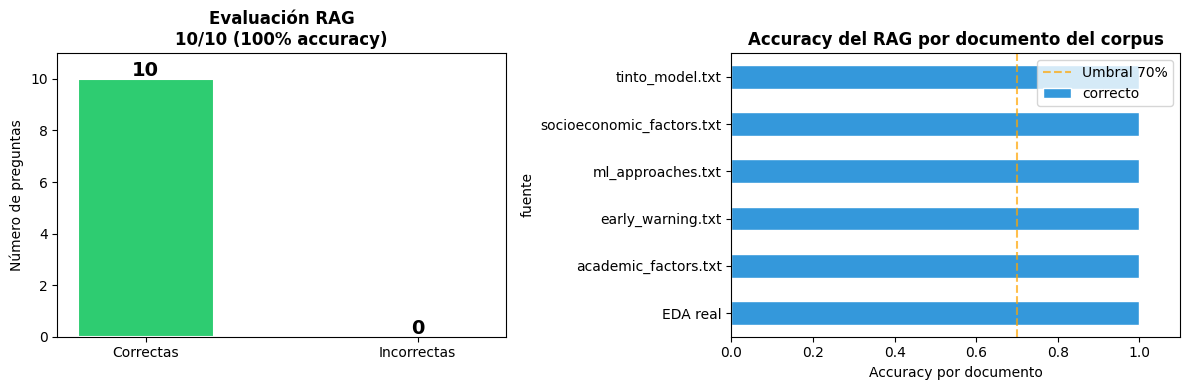

Fig 10 guardada.


In [17]:
# ── Figura de evaluación RAG ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart de correctas vs incorrectas
categorias = ['Correctas', 'Incorrectas']
valores    = [n_correctas, len(EVAL_SET) - n_correctas]
colores    = ['#2ecc71', '#e74c3c']
axes[0].bar(categorias, valores, color=colores, edgecolor='white', linewidth=1.5, width=0.5)
for i, v in enumerate(valores):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=14)
axes[0].set_ylim(0, len(EVAL_SET) + 1)
axes[0].set_ylabel('Número de preguntas')
axes[0].set_title(f'Evaluación RAG\n{n_correctas}/{len(EVAL_SET)} ({accuracy_rag:.0%} accuracy)',
                  fontsize=12, fontweight='bold')

# Resultados por fuente
df_eval = pd.DataFrame(resultados_eval)
acc_fuente = df_eval.groupby('fuente')['correcto'].mean().sort_values()
acc_fuente.plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_xlabel('Accuracy por documento')
axes[1].set_title('Accuracy del RAG por documento del corpus', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 1.1)
axes[1].axvline(x=0.7, color='orange', linestyle='--', alpha=0.7, label='Umbral 70%')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/figures/10_evaluacion_rag.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig 10 guardada.')

## 9. Resumen de Fase 3

In [18]:
print('=== RESUMEN FASE 3 ===')
print(f'LLM utilizado:          llama-3.1-8b-instant (Groq — gratuito)')
print(f'Embeddings:             all-MiniLM-L6-v2 (HuggingFace — gratuito)')
print(f'Vector store:           ChromaDB local ({CHROMA_PATH})')
print(f'Documentos en corpus:  {len(txt_files)} papers sobre deserción estudiantil')
print(f'Chunks indexados:       {vectorstore._collection.count()}')
print(f'Nodos LangGraph:        4 agentes (EDA, RAG, ML, Sintetizador)')
print(f'Patron de ejecucion:    Fan-out paralelo (EDA+RAG) → ML → Síntesis')
print(f'Evaluación RAG:         {n_correctas}/{len(EVAL_SET)} ({accuracy_rag:.0%} accuracy)')
print()
print('Checklist Fase 3:')
print('  [Must] Componente IA generativa integrado con proposito claro         [OK]')
print('  [Must] Todos los prompts documentados y justificados                  [OK]')
print('  [Should] Evaluacion cuantitativa del componente RAG (10 QA pairs)    [OK]')
print('  [Should] LLM API gratuita (Groq)                                     [OK]')
print('  [Nice]  Sistema de agentes con LangGraph — fan-out paralelo          [OK]')
print()
print('Proximo paso: Fase 4 — Informe LaTeX en Overleaf')

=== RESUMEN FASE 3 ===
LLM utilizado:          llama-3.1-8b-instant (Groq — gratuito)
Embeddings:             all-MiniLM-L6-v2 (HuggingFace — gratuito)
Vector store:           ChromaDB local (../chroma_db/)
Documentos en corpus:  5 papers sobre deserción estudiantil
Chunks indexados:       29
Nodos LangGraph:        4 agentes (EDA, RAG, ML, Sintetizador)
Patron de ejecucion:    Fan-out paralelo (EDA+RAG) → ML → Síntesis
Evaluación RAG:         10/10 (100% accuracy)

Checklist Fase 3:
  [Must] Componente IA generativa integrado con proposito claro         [OK]
  [Must] Todos los prompts documentados y justificados                  [OK]
  [Should] Evaluacion cuantitativa del componente RAG (10 QA pairs)    [OK]
  [Should] LLM API gratuita (Groq)                                     [OK]
  [Nice]  Sistema de agentes con LangGraph — fan-out paralelo          [OK]

Proximo paso: Fase 4 — Informe LaTeX en Overleaf
